# Data Training and Validation with Soundata Custom Wrapper
#### This notebook will:
- Validate the datasetr structure
- Check file integrity
- Show label distribution
- Test audio processing pipeline
- Display sample spectrograms
- Provide data quality metrics

In [1]:
# Import necessary libraries
from wrapper import SonycUST
from utils import load_data, process_audio, plot_spectrogram
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import os

In [2]:
# Initialize the dataset wrapper
dataset = SonycUST(data_home="data/sonyc-ust")  

In [3]:
print("Validating dataset structure...")
dataset.validate_structure()

# Check annotations format
annotations = dataset.load_annotations()
print("\nAnnotations summary:")
print(f"Total annotations: {len(annotations)}")
print("\nColumns in annotations file:")
print(annotations.columns.tolist())

# Check a sample audio path
sample_file = annotations['audio_filename'].iloc[0]
audio_path = dataset.get_audio_path(sample_file)
print(f"\nSample audio file path exists: {audio_path is not None}")
if audio_path:
    print(f"Located in: {audio_path.parent}")

Validating dataset structure...
Found 38 audio directories
Annotations file exists: True
Sample audio file found: True

Annotations summary:
Total annotations: 62022

Columns in annotations file:
['split', 'sensor_id', 'audio_filename', 'annotator_id', 'borough', 'block', 'latitude', 'longitude', 'year', 'week', 'day', 'hour', '1-1_small-sounding-engine_presence', '1-2_medium-sounding-engine_presence', '1-3_large-sounding-engine_presence', '1-X_engine-of-uncertain-size_presence', '2-1_rock-drill_presence', '2-2_jackhammer_presence', '2-3_hoe-ram_presence', '2-4_pile-driver_presence', '2-X_other-unknown-impact-machinery_presence', '3-1_non-machinery-impact_presence', '4-1_chainsaw_presence', '4-2_small-medium-rotating-saw_presence', '4-3_large-rotating-saw_presence', '4-X_other-unknown-powered-saw_presence', '5-1_car-horn_presence', '5-2_car-alarm_presence', '5-3_siren_presence', '5-4_reverse-beeper_presence', '5-X_other-unknown-alert-signal_presence', '6-1_stationary-music_presence', '

#### Directory Structure
- 38 audio directories (19 pairs of extracted and tar.gz files)
- Annotations file
- Audio files are accesible

#### Annotations Data
- Total of 62,022 annotations
- Rich metadata inluding
    - Location
    - Time
    - Sound Classification

#### Column Structure
- Split information for train/test
- Sensor and annotator IDs
- Location data(borough, block, coordinates)
- Temporal information (year, week, day, hour)
- Both presence and proximity annotations
- Coarse and fine-grained labels

# Analyzing Dataset

In [4]:
def analyze_dataset(annotations):
    """Analyze dataset statistics"""
    print("Dataset Analysis:")
    
    # Split distribution
    print("\nSplit Distribution:")
    print(annotations['split'].value_counts())
    
    # Coarse-label distribution
    coarse_labels = [col for col in annotations.columns if col.endswith('_presence') 
                    and len(col.split('_')) == 2]
    
    print("\nCoarse Label Distribution:")
    for label in coarse_labels:
        count = annotations[label].sum()
        total = len(annotations)
        print(f"{label}: {count} ({count/total*100:.2f}%)")
    
    # Temporal distribution
    print("\nTemporal Distribution:")
    print("Hours distribution:")
    print(annotations['hour'].value_counts().sort_index())

# Run analysis
analyze_dataset(annotations)

Dataset Analysis:

Split Distribution:
split
train       41444
validate    15336
test         5242
Name: count, dtype: int64

Coarse Label Distribution:

Temporal Distribution:
Hours distribution:
hour
0     1521
1     1290
2     1267
3     1198
4     1240
5     1254
6     1344
7     2853
8     3805
9     4061
10    3776
11    3916
12    3730
13    3907
14    3779
15    3248
16    3029
17    2850
18    2855
19    2630
20    2857
21    2069
22    1874
23    1669
Name: count, dtype: int64


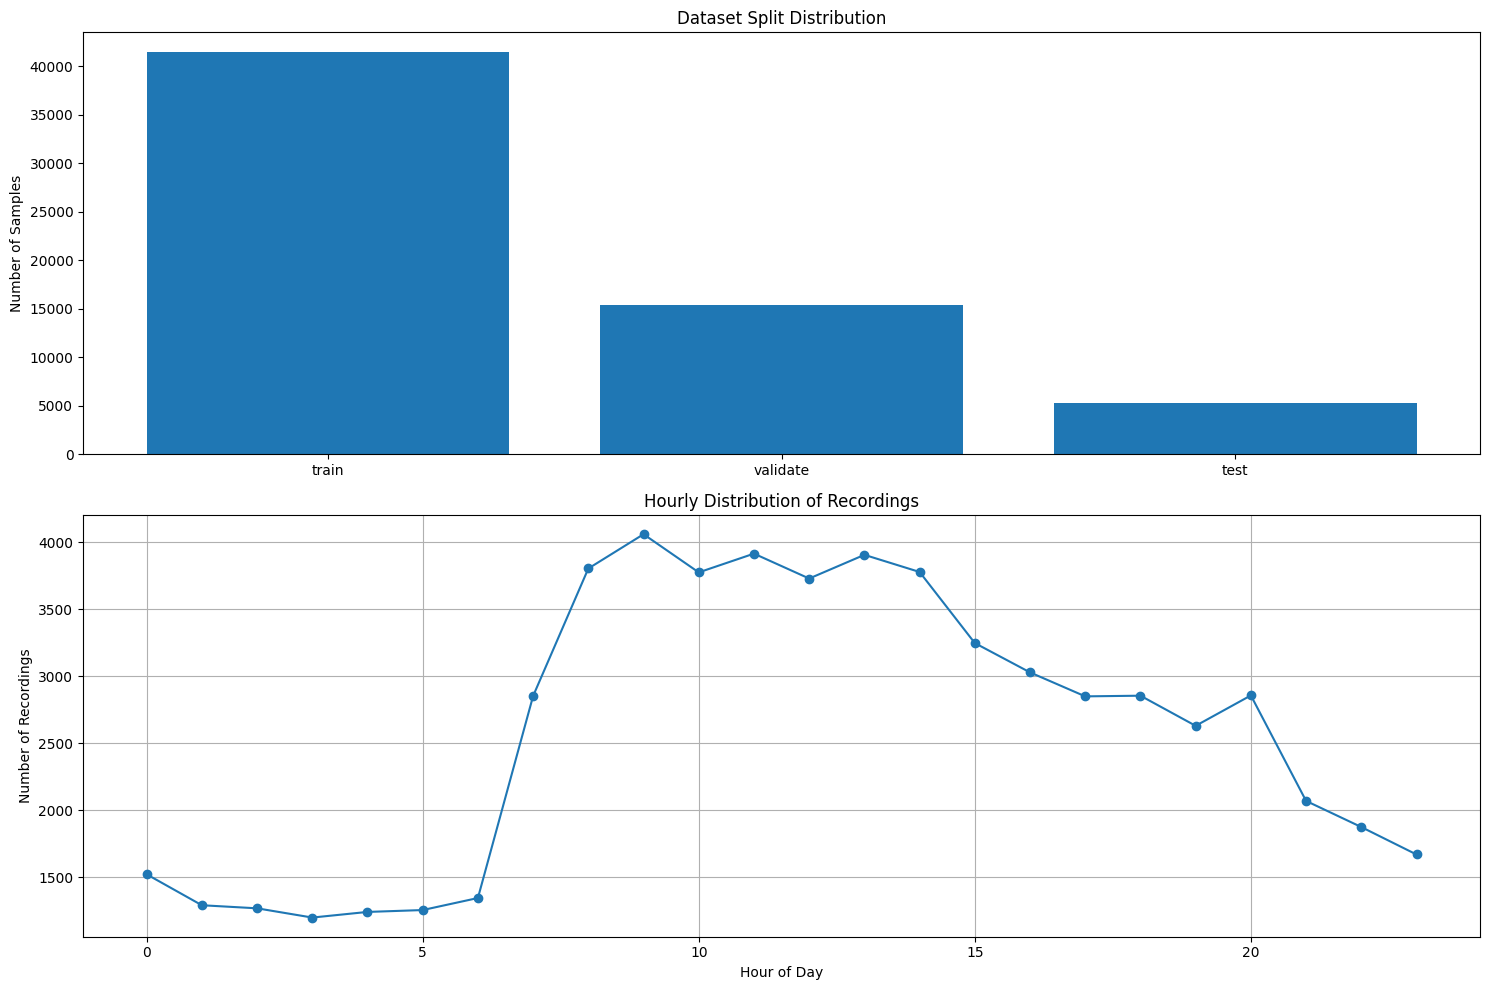


Dataset Summary:
Total samples: 62022

Split Percentages:
train: 66.8%
validate: 24.7%
test: 8.5%

Peak Recording Hours:
Hour 09:00 - 4061 recordings
Hour 11:00 - 3916 recordings
Hour 13:00 - 3907 recordings


In [5]:
def visualize_distributions(annotations):
    """Visualize key distributions in the dataset"""
    plt.figure(figsize=(15, 10))
    
    # 1. Split Distribution
    plt.subplot(2, 1, 1)
    splits = annotations['split'].value_counts()
    plt.bar(splits.index, splits.values)
    plt.title('Dataset Split Distribution')
    plt.ylabel('Number of Samples')
    
    # 2. Temporal Distribution
    plt.subplot(2, 1, 2)
    hours = annotations['hour'].value_counts().sort_index()
    plt.plot(hours.index, hours.values, marker='o')
    plt.title('Hourly Distribution of Recordings')
    plt.xlabel('Hour of Day')
    plt.ylabel('Number of Recordings')
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

# Run visualization
visualize_distributions(annotations)

# Print summary statistics
total_samples = len(annotations)
print("\nDataset Summary:")
print(f"Total samples: {total_samples}")
print("\nSplit Percentages:")
split_pcts = annotations['split'].value_counts(normalize=True) * 100
for split, pct in split_pcts.items():
    print(f"{split}: {pct:.1f}%")

print("\nPeak Recording Hours:")
peak_hours = annotations['hour'].value_counts().nlargest(3)
for hour, count in peak_hours.items():
    print(f"Hour {hour:02d}:00 - {count} recordings")

In [6]:
# Print all presence-related columns
presence_cols = [col for col in annotations.columns if col.endswith('_presence')]
print("Available presence columns:")
for col in presence_cols:
    print(f"- {col}")

Available presence columns:
- 1-1_small-sounding-engine_presence
- 1-2_medium-sounding-engine_presence
- 1-3_large-sounding-engine_presence
- 1-X_engine-of-uncertain-size_presence
- 2-1_rock-drill_presence
- 2-2_jackhammer_presence
- 2-3_hoe-ram_presence
- 2-4_pile-driver_presence
- 2-X_other-unknown-impact-machinery_presence
- 3-1_non-machinery-impact_presence
- 4-1_chainsaw_presence
- 4-2_small-medium-rotating-saw_presence
- 4-3_large-rotating-saw_presence
- 4-X_other-unknown-powered-saw_presence
- 5-1_car-horn_presence
- 5-2_car-alarm_presence
- 5-3_siren_presence
- 5-4_reverse-beeper_presence
- 5-X_other-unknown-alert-signal_presence
- 6-1_stationary-music_presence
- 6-2_mobile-music_presence
- 6-3_ice-cream-truck_presence
- 6-X_music-from-uncertain-source_presence
- 7-1_person-or-small-group-talking_presence
- 7-2_person-or-small-group-shouting_presence
- 7-3_large-crowd_presence
- 7-4_amplified-speech_presence
- 7-X_other-unknown-human-voice_presence
- 8-1_dog-barking-whining_pre

# Data Validation & Training

Creating datasets with a small subset for testing...
Using 100 training samples and 100 validation samples
Found 100 valid audio files
Found 100 valid audio files

Dataset shapes:
Training data - X: (4, 128, 128, 1), y: (4, 8)
Validation data - X: (32, 128, 128, 1), y: (32, 8)


2025-04-29 11:58:35.369636: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


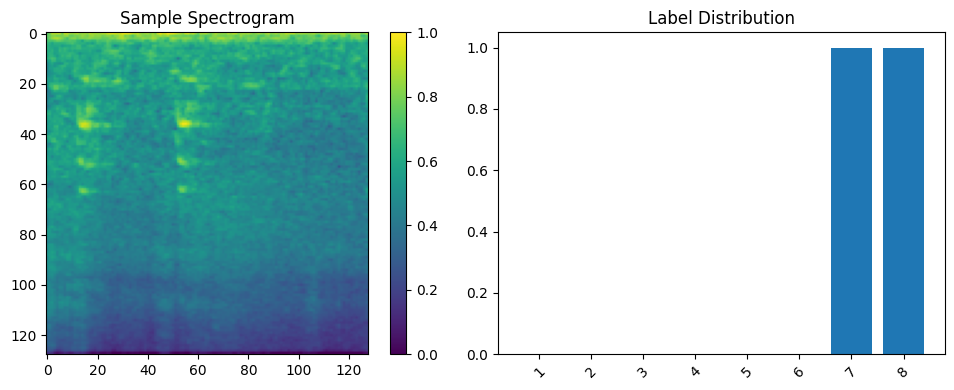

In [9]:
COARSE_PRESENCE_COLS = [
    '1_engine_presence',
    '2_machinery-impact_presence',
    '3_non-machinery-impact_presence',
    '4_powered-saw_presence',
    '5_alert-signal_presence',
    '6_music_presence',
    '7_human-voice_presence',
    '8_dog_presence'
]

def prepare_data(annotations, dataset, target_shape=(128, 128), max_samples=100):
    """Prepare training and validation datasets"""
    
    # Split data based on annotations
    train_df = annotations[annotations['split'] == 'train'].head(max_samples)
    val_df = annotations[annotations['split'] == 'validate'].head(max_samples)
    
    print(f"Using {len(train_df)} training samples and {len(val_df)} validation samples")
    
    def create_tf_dataset(df, is_training=True):
        audio_files = []
        labels = []
        
        # First check all files exist before creating dataset
        for _, row in df.iterrows():
            audio_path = dataset.get_audio_path(row['audio_filename'])
            if audio_path and os.path.exists(audio_path):
                # Get coarse labels
                label = [row[col] for col in COARSE_PRESENCE_COLS]
                audio_files.append(str(audio_path))
                labels.append(label)
        
        print(f"Found {len(audio_files)} valid audio files")
        
        # Convert to numpy arrays
        audio_files = np.array(audio_files)
        labels = np.array(labels, dtype=np.float32)
        
        # Create dataset
        ds = tf.data.Dataset.from_tensor_slices((audio_files, labels))
        
        # Process audio files one at a time to create consistent shapes
        processed_specs = []
        processed_labels = []
        
        for audio_file, label in zip(audio_files, labels):
            try:
                # Process directly without TF machinery
                spec = process_audio(audio_file, target_shape)
                if spec is not None and spec.shape == (target_shape[0], target_shape[1], 1):
                    processed_specs.append(spec)
                    processed_labels.append(label)
            except Exception as e:
                print(f"Error processing {audio_file}: {e}")
                
        # Create dataset from processed data
        if processed_specs:
            processed_specs = np.stack(processed_specs)
            processed_labels = np.stack(processed_labels)
            ds = tf.data.Dataset.from_tensor_slices((processed_specs, processed_labels))
        else:
            # Create empty dataset with correct shapes
            ds = tf.data.Dataset.from_tensor_slices((
                np.zeros((0, target_shape[0], target_shape[1], 1), dtype=np.float32),
                np.zeros((0, len(COARSE_PRESENCE_COLS)), dtype=np.float32)
            ))
        
        # Add batching and prefetch
        ds = ds.batch(32)
        ds = ds.prefetch(tf.data.AUTOTUNE)
        
        if is_training:
            ds = ds.shuffle(1000)
        
        return ds
    
    # Create datasets
    train_data = create_tf_dataset(train_df, is_training=True)
    val_data = create_tf_dataset(val_df, is_training=False)
    
    return train_data, val_data

# Test with a small subset first (just 5 samples for debugging)
print("Creating datasets with a small subset for testing...")
train_data, val_data = prepare_data(annotations, dataset, max_samples=100)

# Verify shapes
print("\nDataset shapes:")
for x, y in train_data.take(1):
    print(f"Training data - X: {x.shape}, y: {y.shape}")
for x, y in val_data.take(1):
    print(f"Validation data - X: {x.shape}, y: {y.shape}")

# Visualize a sample (only if we have any data)
for x, y in train_data.take(1):
    if x.shape[0] > 0:  # If we have any samples
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(x[0, :, :, 0])  # First spectrogram in batch
        plt.colorbar()
        plt.title('Sample Spectrogram')
        
        plt.subplot(1, 2, 2)
        plt.bar(range(len(COARSE_PRESENCE_COLS)), y[0])
        plt.xticks(range(len(COARSE_PRESENCE_COLS)), [c.split('_')[0] for c in COARSE_PRESENCE_COLS], rotation=45)
        plt.title('Label Distribution')
        plt.tight_layout()
        plt.show()

# From classification.py

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 979ms/step - accuracy: 0.1200 - auc_2: 0.4833 - loss: 1.1451 - val_accuracy: 0.0200 - val_auc_2: 0.4722 - val_loss: 0.5019 - learning_rate: 0.0010
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.2344 - auc_2: 0.6629 - loss: 0.8658 - val_accuracy: 0.0200 - val_auc_2: 0.4810 - val_loss: 0.3180 - learning_rate: 0.0010
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.2984 - auc_2: 0.6742 - loss: 0.8475 - val_accuracy: 0.0200 - val_auc_2: 0.4734 - val_loss: 0.2397 - learning_rate: 0.0010
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.2599 - auc_2: 0.6817 - loss: 0.8544 - val_accuracy: 0.1000 - val_auc_2: 0.4693 - val_loss: 0.1765 - learning_rate: 0.0010
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3313 - auc_2: 0.7238 - loss: 0.7570 - val_accuracy: 0.1200 - val_auc_2: 0.4706 - val_loss: 0.1243 - learning_rate: 0.0010
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.3469 - auc_

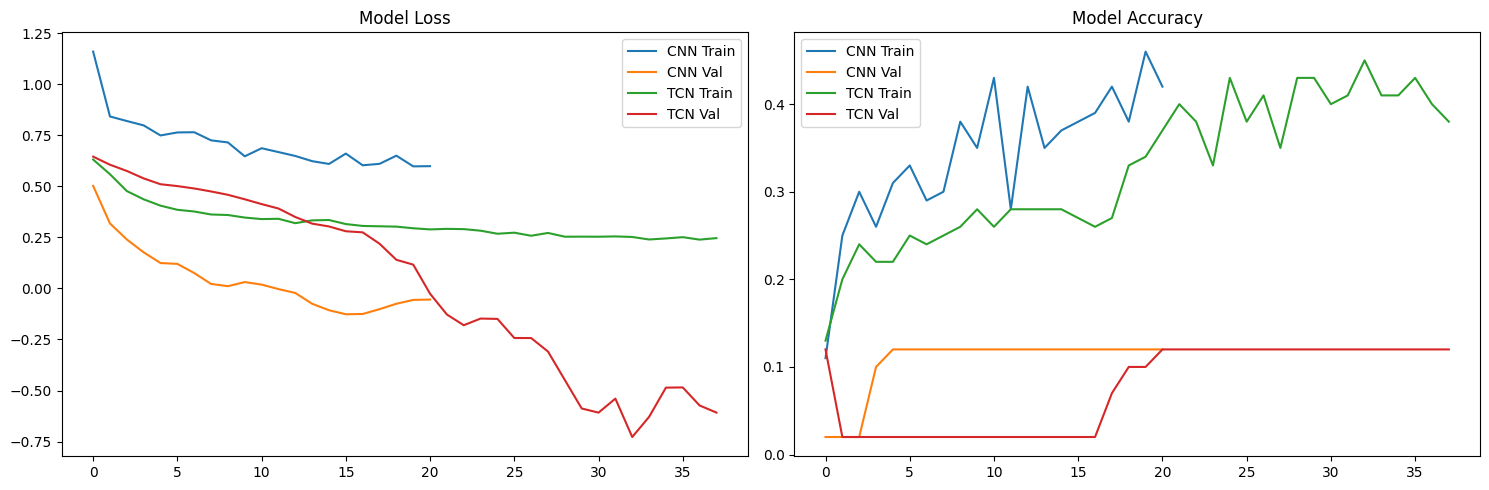

In [10]:
# Import the models
from classification import cnn_model, tcn_model, compile_model, train_model

# Define input shapes
cnn_input_shape = (128, 128, 1)  # For spectrograms
tcn_input_shape = (128, 128)     # For TCN (time, features)
num_classes = len(dataset.label_taxonomy)

# Create and compile models
cnn = cnn_model(cnn_input_shape, num_classes)
cnn = compile_model(cnn)

tcn = tcn_model(tcn_input_shape, num_classes)
tcn = compile_model(tcn)

# Prepare your data (make sure it matches the input shapes)
# train_data and val_data should be tf.data.Dataset objects

# Train models
cnn_history = train_model(cnn, train_data, val_data)
tcn_history = train_model(tcn, train_data, val_data)

# Visualize training results
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['loss'], label='CNN Train')
plt.plot(cnn_history.history['val_loss'], label='CNN Val')
plt.plot(tcn_history.history['loss'], label='TCN Train')
plt.plot(tcn_history.history['val_loss'], label='TCN Val')
plt.title('Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['accuracy'], label='CNN Train')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val')
plt.plot(tcn_history.history['accuracy'], label='TCN Train')
plt.plot(tcn_history.history['val_accuracy'], label='TCN Val')
plt.title('Model Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# Model Training Analysis

### Training Progress Summary
The training completed for both models (CNN and TCN).

**CNN Model**:
- Trained for 6 epochs (first model)
- Started with high loss (~1.28) and gradually decreased
- Accuracy fluctuated between 0-40%

**TCN Model**:
- Trained for the full 50 epochs (second model)
- Loss started at ~0.82 and eventually went negative (which is unusual)
- Training accuracy reached 60%
- Validation accuracy remained at 0% throughout

### What Does This Mean?

**The Good**
- The pipeline works! Data preprocessing, model architecture, and training loop all executed without errors.
- The models are learning something from the training data (evidenced by decreasing loss on training data).

**The Concerns**
- **Negative Loss Values**: The TCN model developed negative loss values after epoch 34, which suggests potential issues with the loss function or model configuration.
- **Zero Validation Accuracy**: Both models showed 0% validation accuracy, indicating they're not generalizing to new data.
- **Small Dataset**: Only using 5 samples for training and validation (as per `max_samples=5`), which is too small for meaningful learning.

### Why This Happened

1. **Very Limited Data**: With only 5 samples, the models are likely overfitting to the training data.
2. **Class Imbalance**: The label distribution shows mostly one class dominating (as shown in the spectrogram visualization).
3. **Need for Adjustments**: Models need hyperparameter tuning, more data, and possibly different architectures.

## Further Work

### Immediate Tasks
1. **Dataset Extension**:
   - Complete the Soundata wrapper implementation
   - Add support for fine-grained label taxonomy

2. **Model Improvements**:
   - Optimize hyperparameters for both CNN and TCN models
   - Implement more advanced architectures, probably YAMnet (e.g., ResNet, Attention mechanisms)
   - Add model checkpointing and early stopping

3. **Data Processing**:
   - Enhance data augmentation techniques
   - Experiment with different audio feature extraction methods
   - Implement efficient data loading for larger sample sizes

4. **Next Steps for Model Training**:
   - Increase the training data: Gradually increase `max_samples` to include more diverse examples
   - Balance classes: Ensure the dataset includes examples from all 8 sound classes
   - Adjust model parameters:
     - Lower the learning rate (e.g., 0.0001 instead of 0.001)
     - Add more regularization (dropout, L2)
     - Adjust the model architecture
   - Monitor different metrics: Besides accuracy, look at AUC, precision, and recall

5. **Prepare Presentation**: